In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt
from scipy.io import arff

In [3]:
data, meta = arff.loadarff('hepatitis.arff') 

df = pd.DataFrame(data)

print(meta)
print(df.head())

Dataset: hepatitis
	AGE's type is numeric
	SEX's type is nominal, range is ('male', 'female')
	STEROID's type is nominal, range is ('no', 'yes')
	ANTIVIRALS's type is nominal, range is ('no', 'yes')
	FATIGUE's type is nominal, range is ('no', 'yes')
	MALAISE's type is nominal, range is ('no', 'yes')
	ANOREXIA's type is nominal, range is ('no', 'yes')
	LIVER_BIG's type is nominal, range is ('no', 'yes')
	LIVER_FIRM's type is nominal, range is ('no', 'yes')
	SPLEEN_PALPABLE's type is nominal, range is ('no', 'yes')
	SPIDERS's type is nominal, range is ('no', 'yes')
	ASCITES's type is nominal, range is ('no', 'yes')
	VARICES's type is nominal, range is ('no', 'yes')
	BILIRUBIN's type is numeric
	ALK_PHOSPHATE's type is numeric
	SGOT's type is numeric
	ALBUMIN's type is numeric
	PROTIME's type is numeric
	HISTOLOGY's type is nominal, range is ('no', 'yes')
	Class's type is nominal, range is ('DIE', 'LIVE')

    AGE        SEX STEROID ANTIVIRALS FATIGUE MALAISE ANOREXIA LIVER_BIG  \
0  30.0

In [6]:
#converting data into numerical values:
from sklearn.preprocessing import LabelEncoder
label_encoder = {}
for column in df.select_dtypes(include='object').columns:
    label_encoder[column] = LabelEncoder()
    df[column] = label_encoder[column].fit_transform(df[column])
    
X = df.drop(columns='Class') #features
y = df['Class']  #target variable

#training and testing datasets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

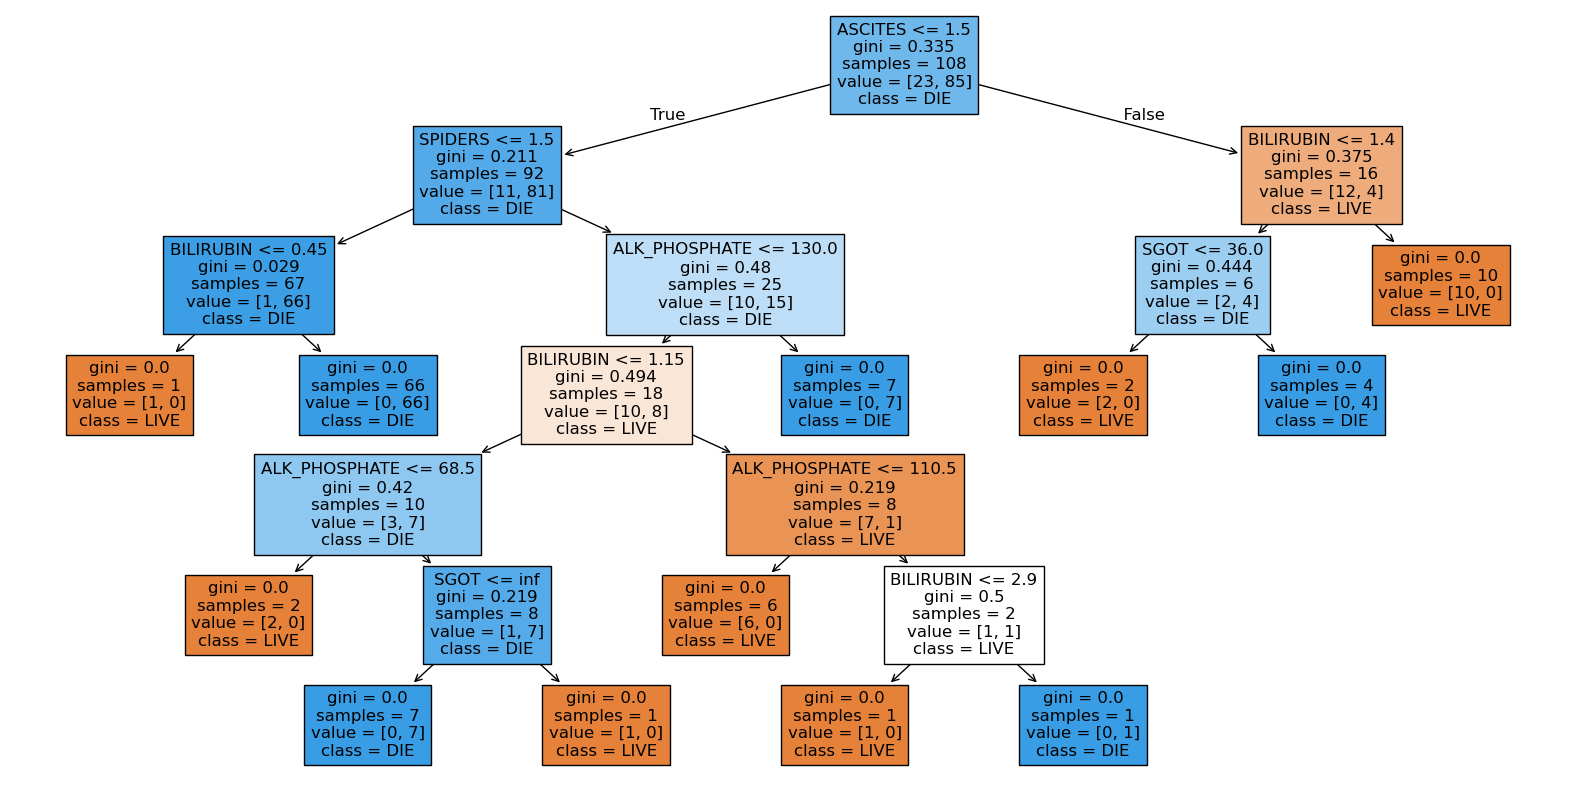

In [7]:
from sklearn.tree import plot_tree
clf = tree.DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['LIVE', 'DIE'], filled=True)
plt.show()

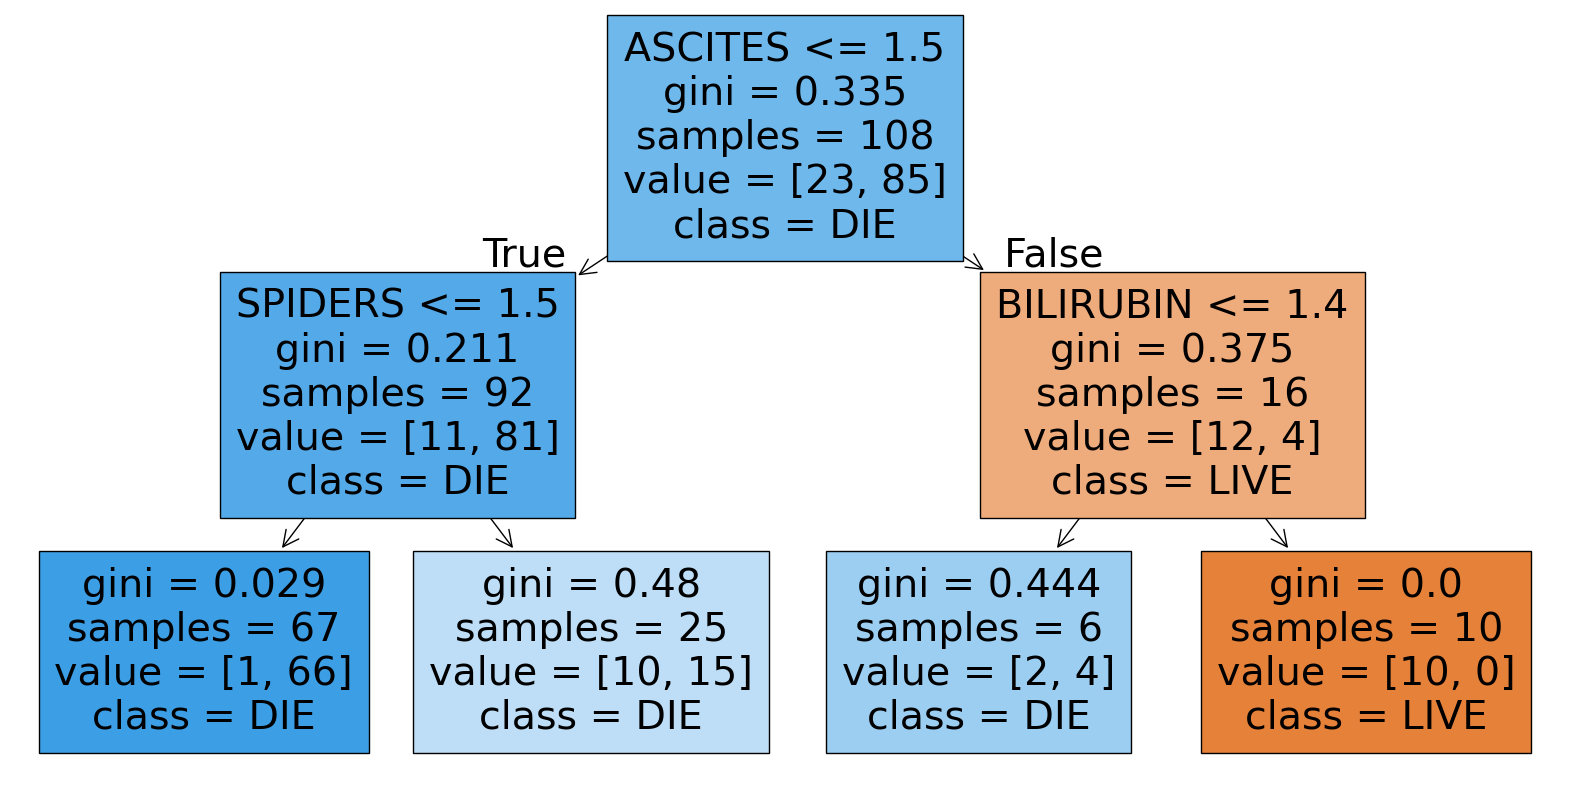

In [15]:
# Decision tree with pruning (using Minimum description Lenght, MDL)
pruned_clf = tree.DecisionTreeClassifier(random_state=42, ccp_alpha=0.03)
pruned_clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(pruned_clf, feature_names=X.columns,class_names=['LIVE','DIE'], filled=True)
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions
y_pred = clf.predict(X_test)
y_pred_pruned = pruned_clf.predict(X_test)

# Evaluate performance
print("Original Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Pruned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pruned))
print("Classification Report:")
print(classification_report(y_test, y_pred_pruned))

Original Decision Tree Accuracy: 0.723404255319149
Pruned Decision Tree Accuracy: 0.7872340425531915
Confusion Matrix:
[[ 0  9]
 [ 1 37]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.80      0.97      0.88        38

    accuracy                           0.79        47
   macro avg       0.40      0.49      0.44        47
weighted avg       0.65      0.79      0.71        47



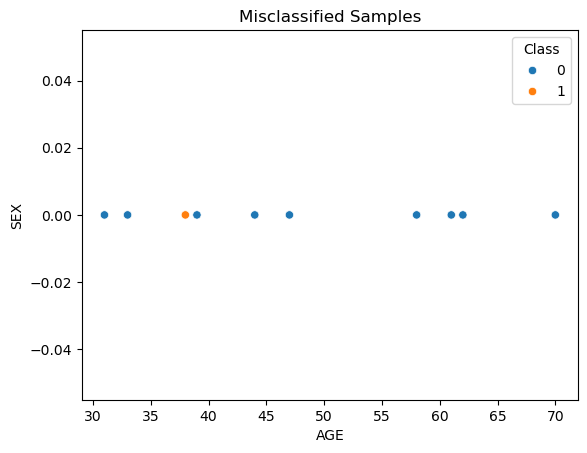

In [17]:
import seaborn as sns
# Compare predicted and actual classes
wrong_predictions = np.where(y_pred_pruned != y_test)[0]
wrong_samples = X_test.iloc[wrong_predictions]

# Visualize misclassified samples
sns.scatterplot(x=wrong_samples.iloc[:, 0], y=wrong_samples.iloc[:, 1], hue=y_test.iloc[wrong_predictions])
plt.title("Misclassified Samples")
plt.show()

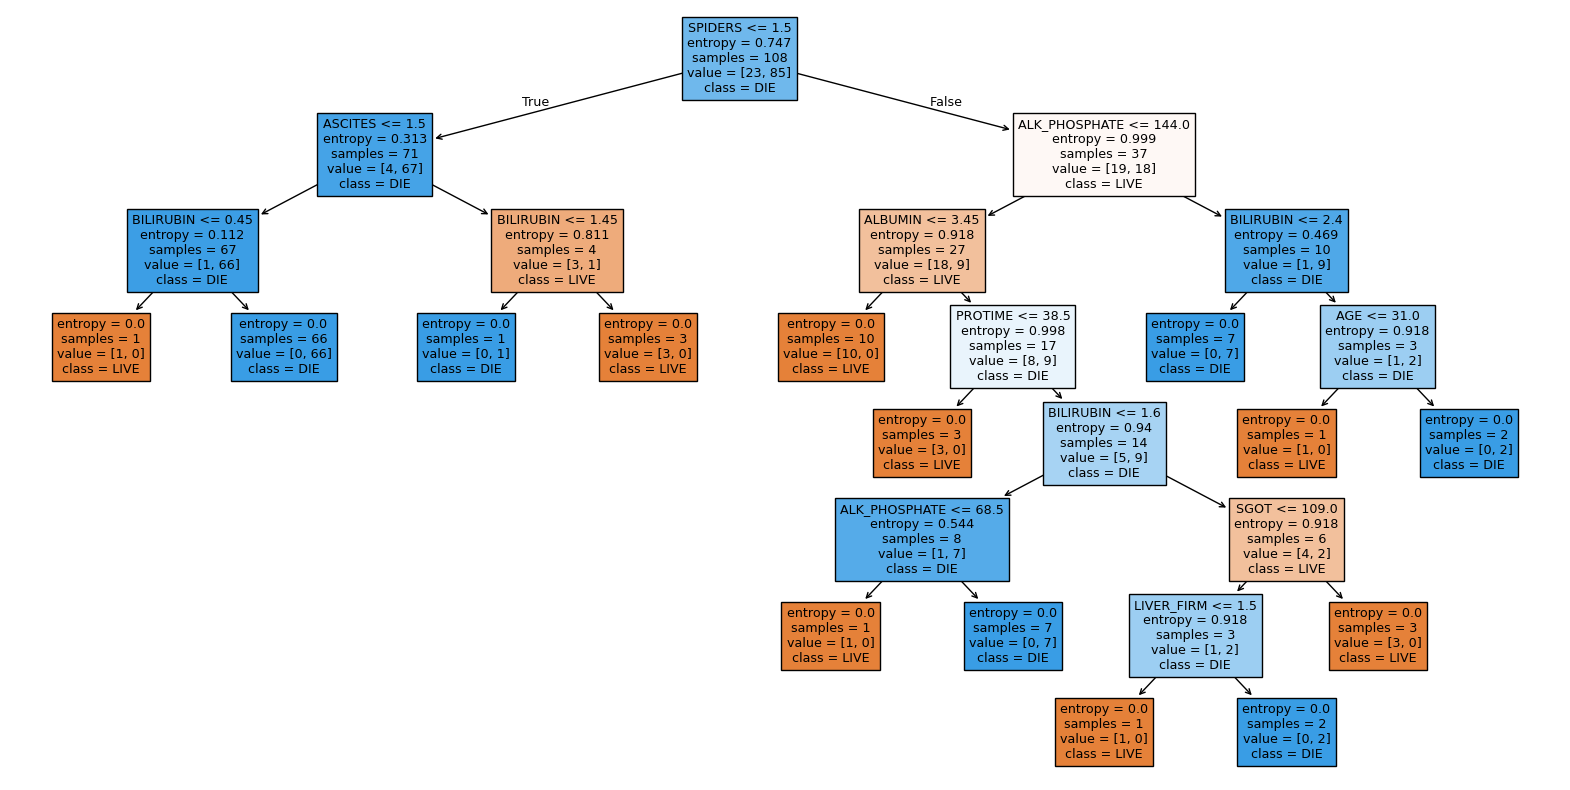

In [20]:
# Train a decision tree using entropy (similar to J48)
j48_clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
j48_clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(j48_clf, feature_names=X.columns,class_names=['LIVE','DIE'], filled=True)
plt.show()

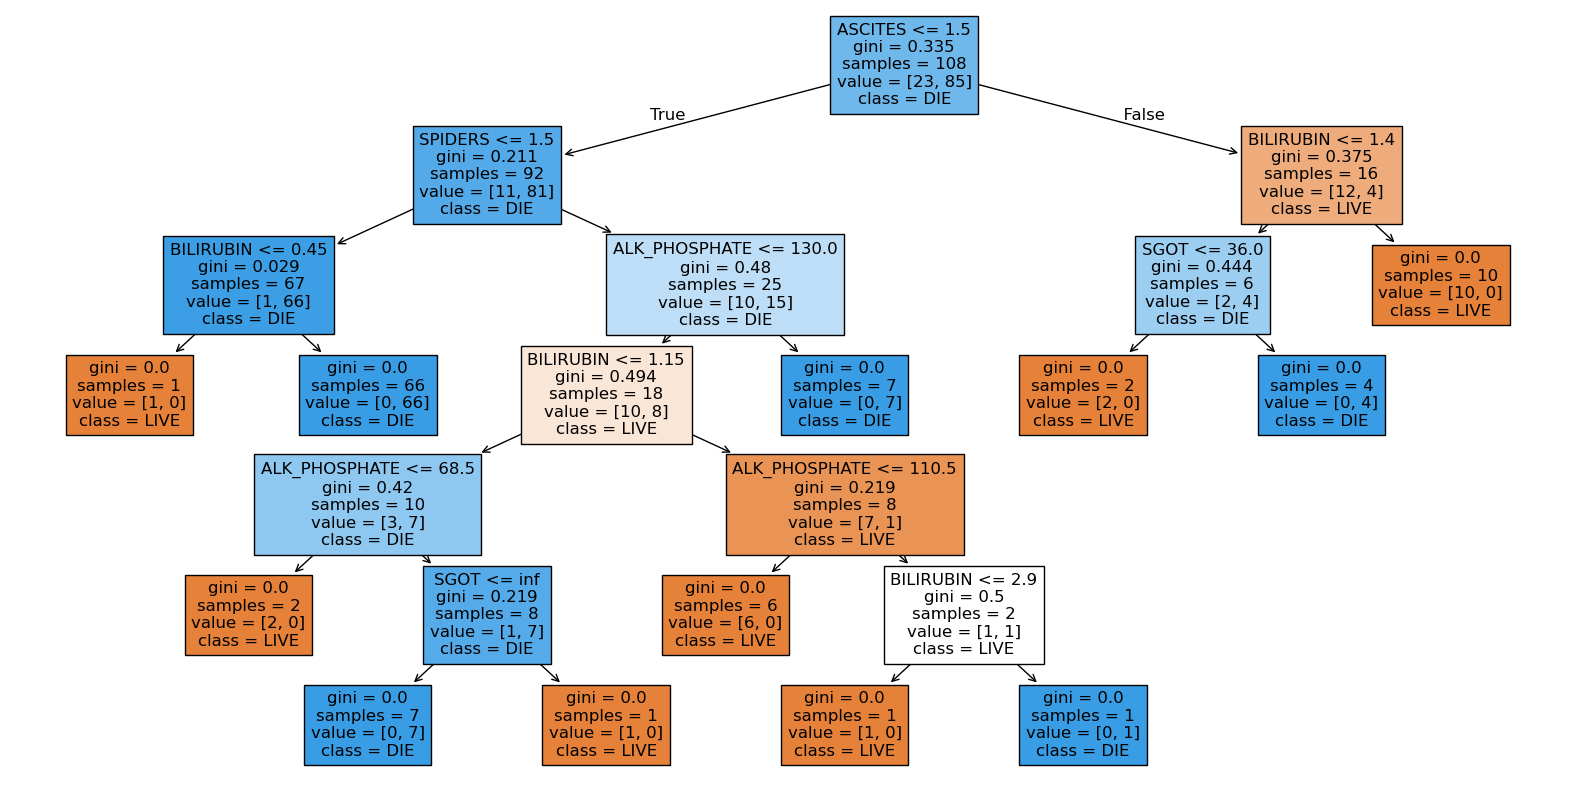

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Train a rule-based classifier (similar to Prism)
rule_based_clf = DecisionTreeClassifier(max_depth=10, random_state=42)
rule_based_clf.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(rule_based_clf, feature_names=X.columns,class_names=['LIVE','DIE'], filled=True)
plt.show()

In [25]:
# Make predictions
y_pred = j48_clf.predict(X_test)
y_pred_pruned = rule_based_clf.predict(X_test)

# Evaluate performance
print("j48_clf Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("rule_based_clf Decision Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_pruned))
print("Classification Report:")
print(classification_report(y_test, y_pred_pruned))

j48_clf Decision Tree Accuracy: 0.7446808510638298
rule_based_clf Decision Tree Accuracy: 0.723404255319149
Confusion Matrix:
[[ 2  7]
 [ 6 32]]
Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.22      0.24         9
           1       0.82      0.84      0.83        38

    accuracy                           0.72        47
   macro avg       0.54      0.53      0.53        47
weighted avg       0.71      0.72      0.72        47

